In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean TotalCharges
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Check dataset
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

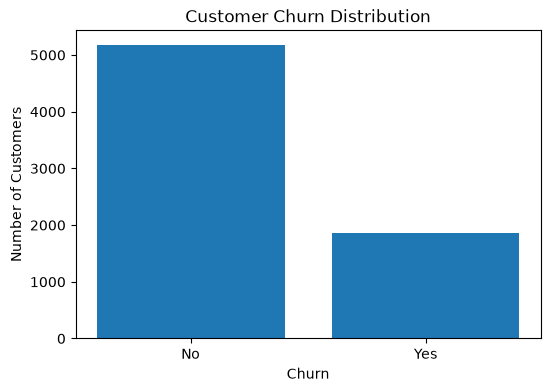

In [2]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [3]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


In [5]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


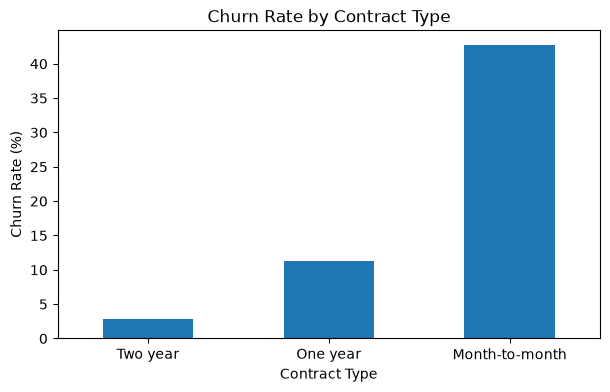

In [6]:
contract_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [7]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [8]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

Churn                No        Yes
TenureGroup                       
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176


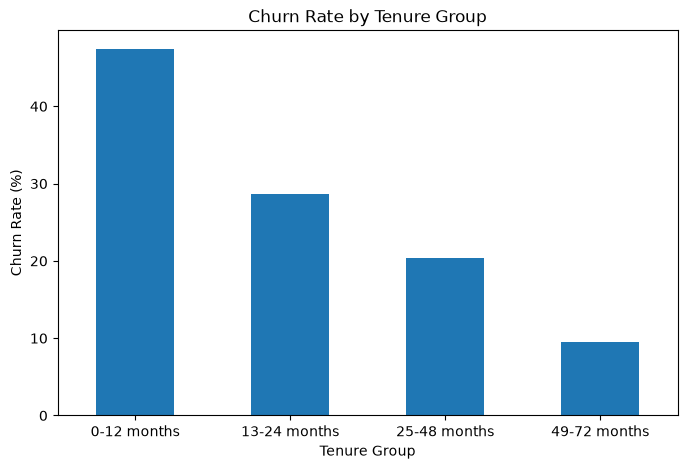

In [9]:
plt.figure(figsize=(8, 5))

tenure_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

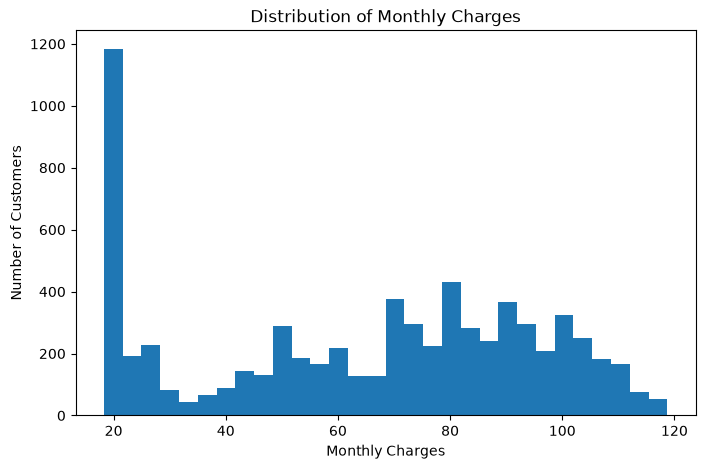

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["MonthlyCharges"],
    bins=30
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [11]:
print(
    df.groupby("Churn")["MonthlyCharges"].agg(
        ["count", "mean", "median", "min", "max"]
    )
)

       count       mean  median    min     max
Churn                                         
No      5174  61.265124  64.425  18.25  118.75
Yes     1869  74.441332  79.650  18.85  118.35


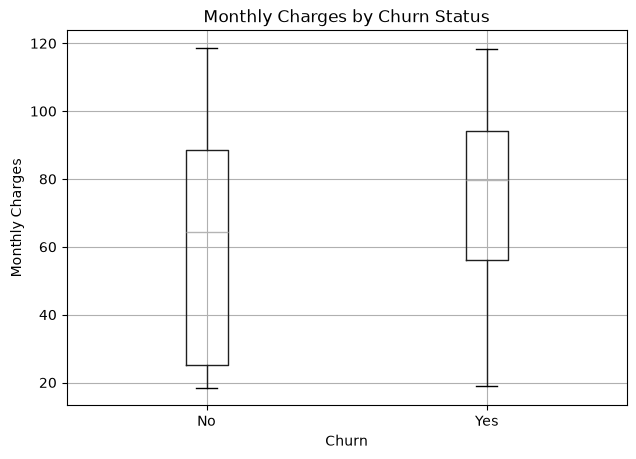

In [12]:
df.boxplot(
    column="MonthlyCharges",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [13]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


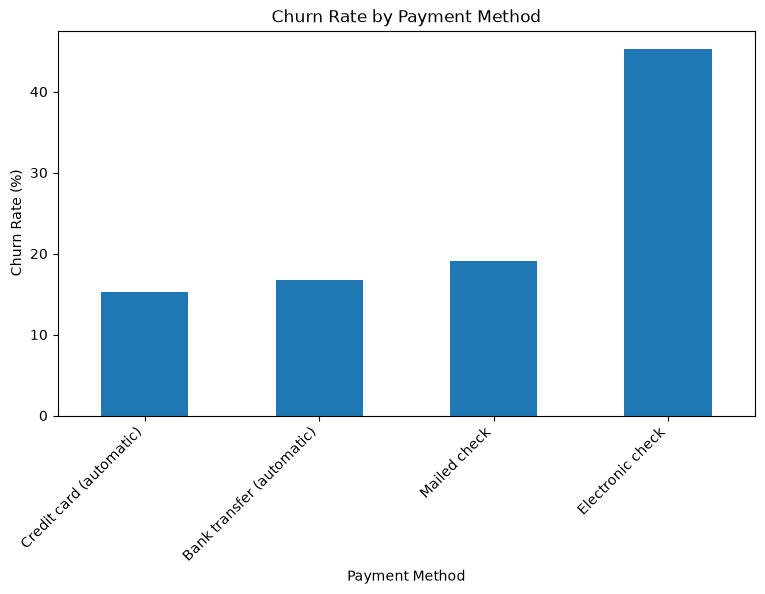

In [14]:
payment_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

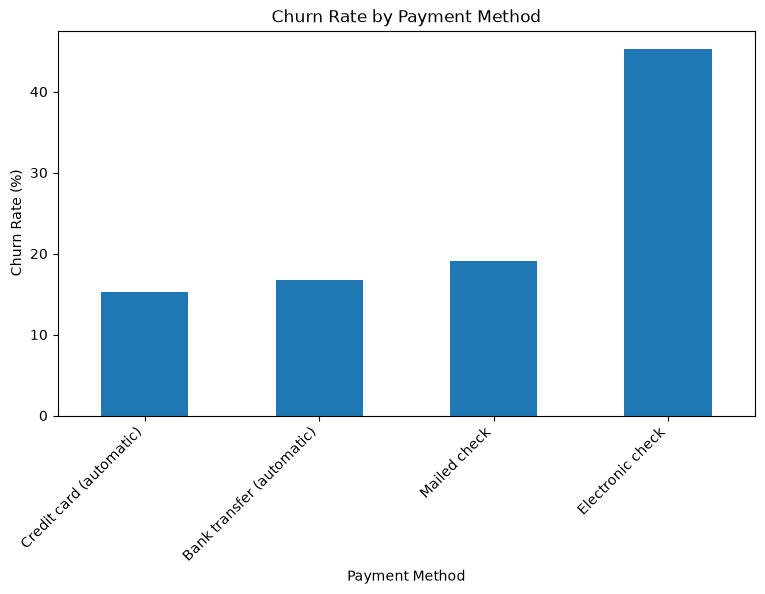

In [15]:
payment_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()


TechSupport
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


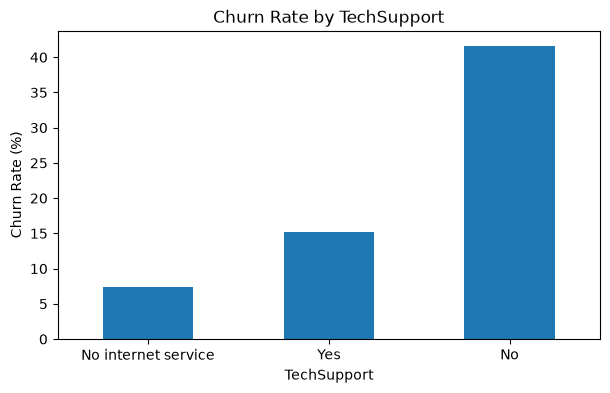


OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


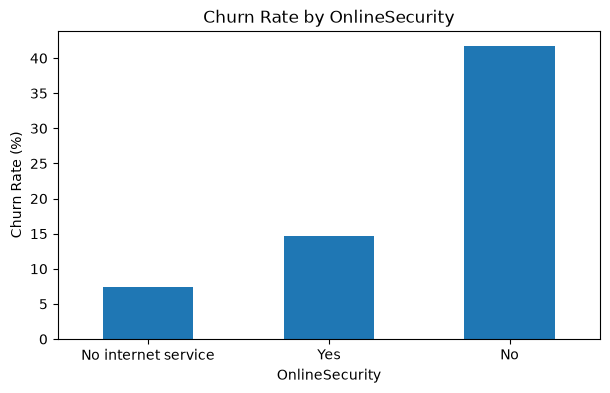


OnlineBackup
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494


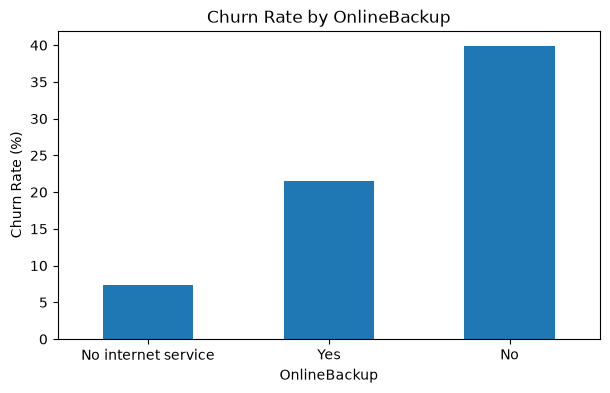


DeviceProtection
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064


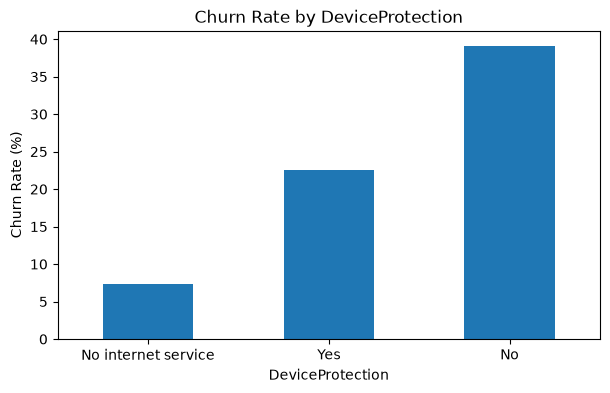

In [16]:
service_columns = [
    "TechSupport",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection"
]

for column in service_columns:

    service_churn = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

    print("\n==============================")
    print(column)
    print("==============================")
    print(service_churn)

    plt.figure(figsize=(7, 4))

    service_churn["Yes"].sort_values().plot(
        kind="bar"
    )

    plt.title(f"Churn Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=0)

    plt.show()

===== CHURN BY INTERNET SERVICE =====
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


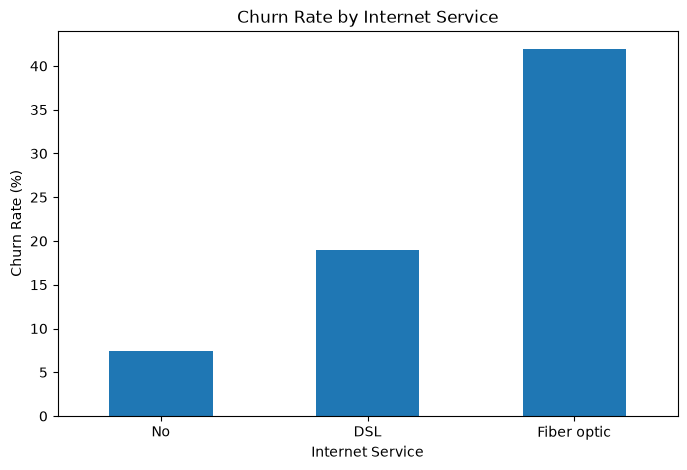


CHURN BY TechSupport
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


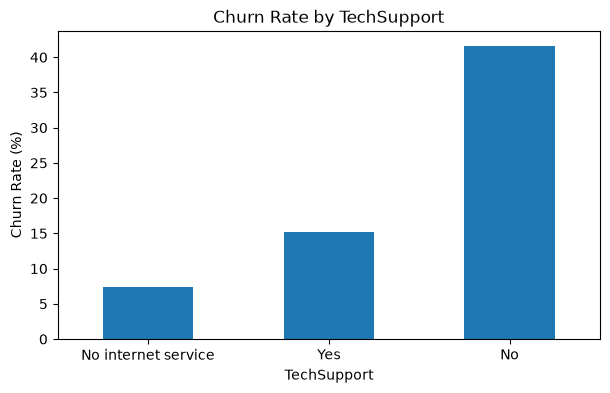


CHURN BY OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


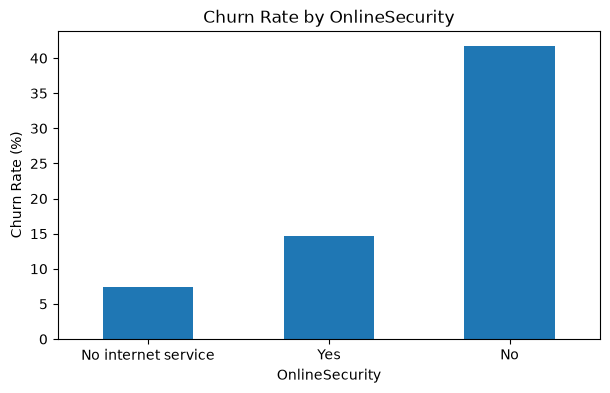


CHURN BY OnlineBackup
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494


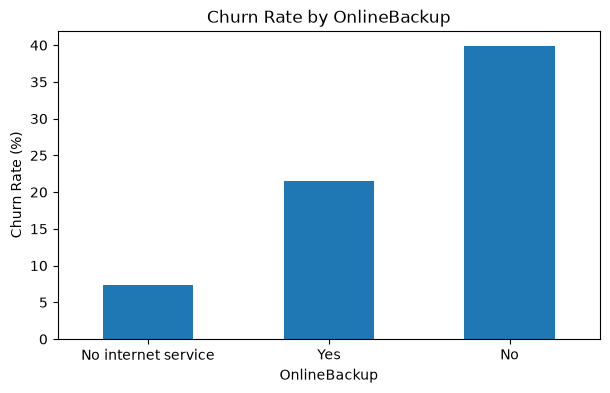


CHURN BY DeviceProtection
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064


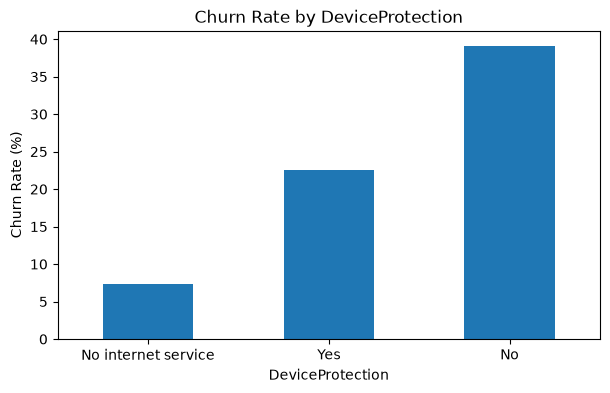


===== SERVICE COUNT CREATED =====
ServiceCount
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

===== CHURN BY SERVICE COUNT =====
Churn                No        Yes
ServiceCount                      
0             78.593961  21.406039
1             54.244306  45.755694
2             64.181994  35.818006
3             72.629696  27.370304
4             77.699531  22.300469
5             87.565674  12.434326
6             94.718310   5.281690


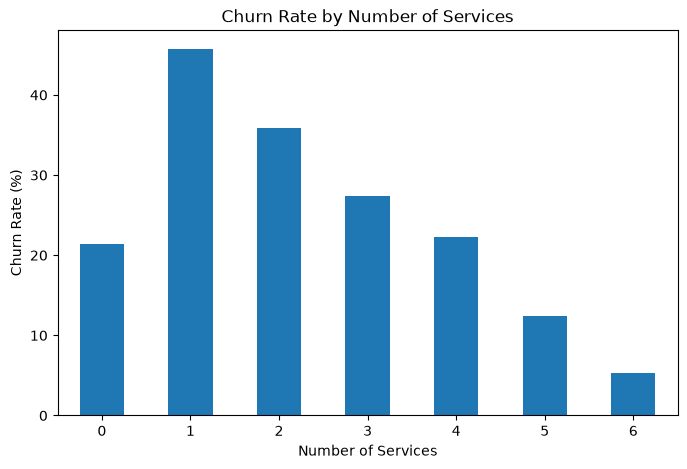


===== CHURN BY MONTHLY CHARGE SEGMENT =====
Churn                        No        Yes
MonthlyChargeSegment                      
Low                   84.134411  15.865589
Medium                70.319829  29.680171
High                  65.913933  34.086067


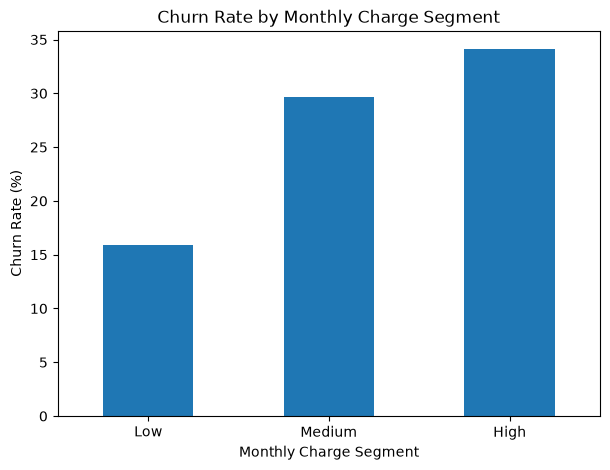

In [19]:
# ============================================
# SERVICE ANALYSIS
# ============================================

import matplotlib.pyplot as plt
import pandas as pd


# ============================================
# 1. INTERNET SERVICE
# ============================================

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("===== CHURN BY INTERNET SERVICE =====")
print(internet_churn)

internet_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()


# ============================================
# 2. SUPPORT SERVICES
# ============================================

support_columns = [
    "TechSupport",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection"
]

for column in support_columns:

    service_churn = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

    print("\n==============================")
    print("CHURN BY", column)
    print("==============================")
    print(service_churn)

    service_churn["Yes"].sort_values().plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.title(f"Churn Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=0)
    plt.show()


# ============================================
# 3. CREATE SERVICE COUNT
# ============================================

all_service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (
    df[all_service_columns] == "Yes"
).sum(axis=1)

print("\n===== SERVICE COUNT CREATED =====")
print(df["ServiceCount"].value_counts().sort_index())


# ============================================
# 4. SERVICE COUNT VS CHURN
# ============================================

service_count_churn = pd.crosstab(
    df["ServiceCount"],
    df["Churn"],
    normalize="index"
) * 100

print("\n===== CHURN BY SERVICE COUNT =====")
print(service_count_churn)

service_count_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()


# ============================================
# 5. MONTHLY CHARGE SEGMENTS
# ============================================

df["MonthlyChargeSegment"] = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

segment_churn = pd.crosstab(
    df["MonthlyChargeSegment"],
    df["Churn"],
    normalize="index"
) * 100

print("\n===== CHURN BY MONTHLY CHARGE SEGMENT =====")
print(segment_churn)

segment_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Monthly Charge Segment")
plt.xlabel("Monthly Charge Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()